### Лабораторная работа №8
### "Регрессионный анализ данных"

#### **Регрессионный анализ** – это статистический метод для количественного определения (предсказания) значения одной переменной на основании другой (других). Как одна (или несколько) переменная(ых) влияет на другую переменную?

#### **Цели:**
- Предсказание значения зависимой
переменной с помощью независимых
переменных.
Какая будет оценка в зависимости от того,
сколько часов потрачено на подготовку?
- Измерение влияния отдельных
независимых переменных на зависимую
переменную (расширение
корреляционного анализа на нелинейные
зависимости).

#### Виды:
- ОДНОФАКТОРНАЯ линейная(нелинейная) связь   
независимая переменная(категориальная, порядковая,количественная) -> зависимая переменная(количественная)  
- МНОГОФАКТОРНАЯ линейная(нелинейная) связь   
независимая переменная(категориальная, порядковая,количественная) -> зависимая переменная(количественная)   
- ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ    
независимая переменная(категориальная, порядковая,количественная) -> зависимая переменная(категориальная с двумя категориями)  

    
   
Наблюдаемое значение отклика y можно мысленно разделить на две части:

y = f(x) + epsilon

где:
- f(x) — функциональная закономерность между y и x
- epsilon — случайная величина (погрешность, неучтённые факторы)

Для каждого наблюдения: $y_i = f(x_i) + epsilon_i$, i = 1...n

ВАЖНО: Реально нам неизвестны ни $f(x_i)$, ни $epsilon_i$. Из опыта мы знаем только их сумму $y_i$.

ПРЕДПОЛОЖЕНИЯ ОБ ОШИБКАХ $epsilon_i$ (КЛАССИЧЕСКАЯ МОДЕЛЬ):

а) $ε_i$ — независимые случайные величины

б) $ε_i$ имеют одинаковый закон распределения

в) $ε_i$ ∈ N(0, sigma^2) — нормальное распределение с нулевым матожиданием

ПОЧЕМУ НОРМАЛЬНОЕ РАСПРЕДЕЛЕНИЕ?

Ошибка (погрешность) складывается из большого числа случайных факторов, которые мы не учитываем. Согласно Центральной Предельной Теореме (ЦПТ), их сумма имеет нормальный закон распределения.

По данным Всемирной организации здравоохранения (ВОЗ), инсульт является второй 
по значимости причиной смерти в мире, на него приходится около 11% всех смертей. 
Используйте данные, представленные в файле healthcare-dataset-stroke-data.csv для 
прогнозирования вероятности инсульта у пациента на основе таких входных параметров, как 
пол, возраст, различные заболевания и статус курения. Каждая строка в данных содержит 
релевантную информацию о пациенте. 
Информация о переменных:
1) id: уникальный идентификатор;
2) gender: «Мужской», «Женский», «Другой»;
3) age: возраст пациента;
4) hypertension: 0, если у пациента нет гипертензии, 1, если у пациента есть 
гипертензия;
5) heart_disease: 0, если у пациента нет никаких заболеваний сердца, 1, если у пациента 
есть заболевание сердца;
6) ever_married: «Нет» или «Да»;
7) work_type: «Ребенок», «Государственное учреждение», «Никогда не работал», 
«Негосударственная (частная) компания», «Самозанятый»;
8) Residence_type: место проживания «Сельское» или «Городское»;
9) avg_glucose_level: средний уровень глюкозы в крови;
10) bmi: индекс массы тела;
11) smoking_status: «ранее курил», «никогда не курил», «курит» или «Неизвестно»*
(«Неизвестно» в smoking_status означает, что информация для этого пациента 
недоступна);
12) stroke: 1, если у пациента был инсульт или 0, если нет.

### *Задание №1. Исследовать влияние возраста человека на (age) на индекс массы тела (bmi).*
### 1.1 Подготовить данные для анализа.
(убрать пустые значения, привести значения к нужному формату)

In [12]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Выбор переменных age (независимая) и bmi (зависимая)
df_clean = df[['age', 'bmi']].copy()

# Удаление пустых значений
df_clean = df_clean.dropna()

# Приведение к нужному формату (числовые)
df_clean['age'] = pd.to_numeric(df_clean['age'])
df_clean['bmi'] = pd.to_numeric(df_clean['bmi'])


## *1.2 Для зависимой и независимой переменных сделать визуализацию данных, т.е. построить:*
- диаграмму рассеяния (scatter plot),
- гистограммы (hist),
- коробчатые диаграммы (boxplot) Знать, что означает каждая линия и box на данном графике.

Цель: визуально оценить распределение переменных и наличие связи между ними.

| Тип графика | Что показывает | Как интерпретировать |
|-------------|----------------|----------------------|
| **Диаграмма рассеяния (scatter plot)** | Связь между двумя количественными переменными  | Точки вытянуты вверх => положительная связь. Точки вытянуты вниз  => отрицательная связь. Узкая полоса => сильная связь. Широкий разброс => слабая связь. Круг/шар => связи нет. Дуга => нелинейная связь. Отдельные группы =>  категориальная зависимость |
| **Гистограмма (histogram)** | Распределение одной переменной | Колокол => нормальное распределение. Скошена вправо => много маленьких значений. Скошена влево => много больших значений. Два пика => две разные группы в данных |
| **Коробчатая диаграмма (boxplot)** | Медиану, квартили и выбросы одной переменной  | **Линии на boxplot:**<br>• Нижняя граница "уса" — Q1 − 1.5×IQR или min (без выбросов)<br>• Нижняя линия коробки — Q1 (25% данных ниже)<br>• Линия внутри коробки — медиана (Q2, 50% данных ниже)<br>• Верхняя линия коробки — Q3 (75% данных ниже)<br>• Верхняя граница "уса" — Q3 + 1.5×IQR или max<br>• Точки за усами — выбросы (аномальные значения) |

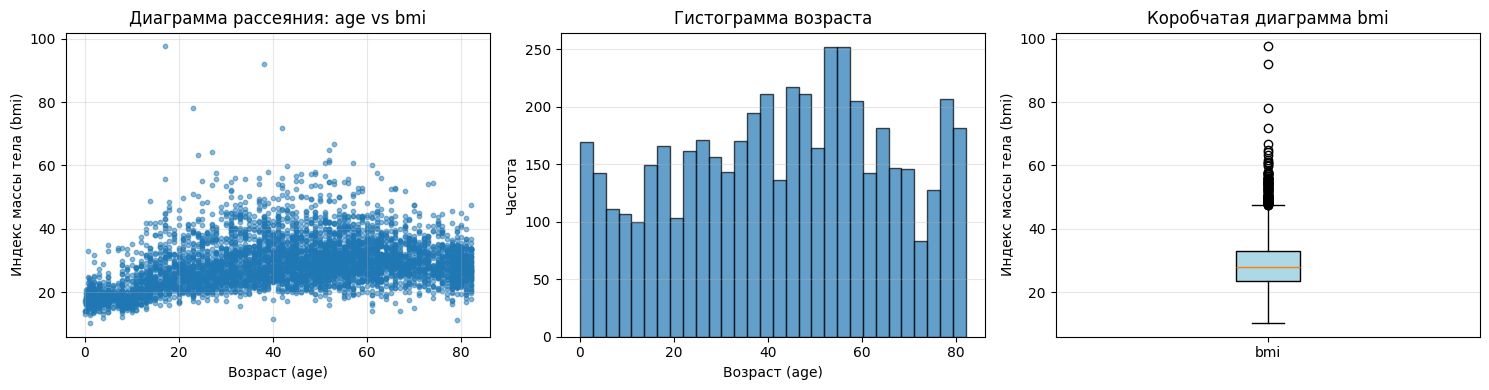


Пояснение К boxplot (bmi):
  Медиана: 28.10
  Q1 (25-й процентиль): 23.50
  Q3 (75-й процентиль): 33.10
  IQR (Q3 - Q1): 9.60
  Минимум (без выбросов): 9.10
  Максимум (без выбросов): 47.50


In [13]:
import matplotlib.pyplot as plt

x = df_clean['age'] # независимая переменная (возраст)
y = df_clean['bmi'] # зависимая переменная (индекс массы тела)

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # 3 графика в одной строке

# 1. Диаграмма рассеяния
axes[0].scatter(x, y, alpha=0.5, s=10) # точки с прозрачностью 0.5, размер 10
axes[0].set_xlabel('Возраст (age)') # подпись оси X
axes[0].set_ylabel('Индекс массы тела (bmi)') # подпись оси Y
axes[0].set_title('Диаграмма рассеяния: age vs bmi') # заголовок
axes[0].grid(alpha=0.3) # сетка с прозрачностью
# Направление: слабо положительное (с возрастом bmi немного растёт)
# Форма: линейная (точек много, но разброс большой)
# Сила связи: слабая (точки широко разбросаны, нет узкой полосы)
# Вывод: возраст слабо связан с индексом массы тела. Молодые люди могут иметь как низкий, так и высокий bmi. 
# Пожилые — тоже. Связь есть, но очень слабая.

# 2. Гистограмма для age
axes[1].hist(x, bins=30, edgecolor='black', alpha=0.7) # 30 интервалов, чёрные границы
axes[1].set_xlabel('Возраст (age)') # подпись оси X
axes[1].set_ylabel('Частота') # подпись оси Y
axes[1].set_title('Гистограмма возраста') # заголовок
axes[1].grid(axis='y', alpha=0.3) # сетка только по Y
# Форма: скошена вправо (или почти равномерная с провалом)
# Что означает: людей молодого возраста (20-30 лет) много, людей пожилого возраста (70-80) меньше,
#  а в районе 50-60 лет наблюдается снижение частоты (провал)
# Вывод: распределение возраста не является нормальным (не колокол). Выборка смещена в сторону молодых людей.

# 3. Коробчатая диаграмма для bmi
bp = axes[2].boxplot(y, vert=True, patch_artist=True) # вертикальный ящик, с заливкой
bp['boxes'][0].set_facecolor('lightblue') # цвет заливки ящика
axes[2].set_ylabel('Индекс массы тела (bmi)') # подпись оси Y
axes[2].set_title('Коробчатая диаграмма bmi') # заголовок
axes[2].set_xticklabels(['bmi']) # подпись оси X
axes[2].grid(axis='y', alpha=0.3) # сетка только по Y
# распределение bmi скошено вправо (медиана ближе к нижней части ящика, есть высокие выбросы). Большинство людей имеют bmi от 24 до 36.

plt.tight_layout() # автоматическое выравнивание
plt.show() # отображение графиков

# Пояснение К boxplot (вывод числовых характеристик)
print("\nПояснение К boxplot (bmi):")
print(f"  Медиана: {y.median():.2f}") # центральное значение (50-й процентиль)
print(f"  Q1 (25-й процентиль): {y.quantile(0.25):.2f}") # нижняя граница ящика
print(f"  Q3 (75-й процентиль): {y.quantile(0.75):.2f}") # верхняя граница ящика
print(f"  IQR (Q3 - Q1): {y.quantile(0.75) - y.quantile(0.25):.2f}") # высота ящика
print(f"  Минимум (без выбросов): {y.quantile(0.25) - 1.5 * (y.quantile(0.75) - y.quantile(0.25)):.2f}") # нижний ус
print(f"  Максимум (без выбросов): {y.quantile(0.75) + 1.5 * (y.quantile(0.75) - y.quantile(0.25)):.2f}") # верхний ус

## 1.3 Проверить гипотезу о нормальном распределении исходных данных:
- количественно, с помощью критериев согласия,
- качественно, на основе визуального анализа (P-P и Q-Q plot). Знать, как строятся
эти графики. В чем их различие, особенности применения.

#### P-P plot и Q-Q plot (качественный анализ)

| График | Что показывает | Как строится | Чувствительность |
|--------|----------------|--------------|------------------|
| **Q-Q plot** (Quantile-Quantile) | Квантили эмпирического распределения vs квантили теоретического нормального распределения | Сортируем данные, сопоставляем каждому значению его теоретический квантиль | Хорошо показывает отклонения в хвостах распределения |
| **P-P plot** (Probability-Probability) | Эмпирические накопленные вероятности vs теоретические накопленные вероятности | Для каждого x сравниваем F_n(x) и F(x) | Чувствителен к отклонениям в центре распределения |

Если точки на графиках лежат близко к диагонали → распределение близко к нормальному.

In [14]:
# ГИПОТЕЗЫ:
# H0: данные имеют НОРМАЛЬНОЕ распределение
# H1: данные НЕ ИМЕЮТ нормального распределения

# ДВА ПОДХОДА К ПРОВЕРКЕ:
# 1. Количественный (критерии согласия) -> p-value
# 2. Качественный (P-P plot и Q-Q plot) -> визуально

from scipy import stats
import numpy as np

print("1.3 ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ")
print("\n1. КОЛИЧЕСТВЕННАЯ ПРОВЕРКА:")

# 1.1 КРИТЕРИЙ ШАПИРО-УИЛКА
# Теория:
# - Статистика W близка к 1 => данные нормальны
# - p-value >= 0.05 -> H0 не отвергается (данные нормальны)
# - Лучший для выборок n < 50

shapiro_age = stats.shapiro(x) # W - статистика, p-value - вероятность
shapiro_bmi = stats.shapiro(y)

print(f"\nКритерий Шапиро-Уилка для age:")
print(f"  Статистика W = {shapiro_age.statistic:.4f}")
print(f"  p-value = {shapiro_age.pvalue:.4e}")
print(f"  Вывод: {'отвергаем H0 (распределение НЕ нормальное)' if shapiro_age.pvalue < 0.05 else 'не отвергаем H0 (распределение нормальное)'}")

print(f"\nКритерий Шапиро-Уилка для bmi:")
print(f"  Статистика W = {shapiro_bmi.statistic:.4f}")
print(f"  p-value = {shapiro_bmi.pvalue:.4e}")
print(f"  Вывод: {'отвергаем H0 (распределение НЕ нормальное)' if shapiro_bmi.pvalue < 0.05 else 'не отвергаем H0 (распределение нормальное)'}")

# 1.2 КРИТЕРИЙ КОЛМОГОРОВА-СМИРНОВА
# Теория:
# - D_n = max |F_n(x_i) - F(x_i; θ)| (максимальное отклонение эмпирической и теоретической функций)
# - Z = √n * D_n (статистика)
# - Если Z < λ_α -> H0 не отвергается (данные нормальны)
# - λ_α для α=0.05: 1.358 (из таблицы презентации)

def kolmogorov_test(data, alpha=0.05):
    n = len(data)
    mu = np.mean(data)
    sigma = np.std(data, ddof=1)
    
    sorted_data = np.sort(data)
    F_n = np.arange(1, n+1) / n
    F_theor = stats.norm.cdf(sorted_data, loc=mu, scale=sigma)
    
    D_n = np.max(np.abs(F_n - F_theor))
    Z = np.sqrt(n) * D_n
    
    lambda_critical = {0.20: 1.073, 0.10: 1.224, 0.05: 1.358, 0.02: 1.520, 0.01: 1.627}
    lambda_alpha = lambda_critical.get(alpha, 1.358)
    
    rejected = Z >= lambda_alpha
    
    return {
        'D_n': D_n, 'Z': Z, 'lambda_alpha': lambda_alpha, 'n': n,
        'rejected': rejected,
        'conclusion': 'отвергаем H0' if rejected else 'не отвергаем H0'
    }

print("\n1.2 Критерий Колмогорова-Смирнова:")

result_age = kolmogorov_test(x, alpha=0.05)
print(f"\nПеременная age (n = {result_age['n']}):")
print(f"  D_n = {result_age['D_n']:.4f}")
print(f"  Z = √n * D_n = {result_age['Z']:.4f}")
print(f"  Критическое значение λ_α (α=0.05) = {result_age['lambda_alpha']:.3f}")
print(f"  Сравнение: Z = {result_age['Z']:.4f} {'≥' if result_age['rejected'] else '<'} λ_α = {result_age['lambda_alpha']:.3f}")
print(f"  Вывод: {result_age['conclusion']} (распределение {'НЕ нормальное' if result_age['rejected'] else 'нормальное'})")

result_bmi = kolmogorov_test(y, alpha=0.05)
print(f"\nПеременная bmi (n = {result_bmi['n']}):")
print(f"  D_n = {result_bmi['D_n']:.4f}")
print(f"  Z = √n * D_n = {result_bmi['Z']:.4f}")
print(f"  Критическое значение λ_α (α=0.05) = {result_bmi['lambda_alpha']:.3f}")
print(f"  Сравнение: Z = {result_bmi['Z']:.4f} {'≥' if result_bmi['rejected'] else '<'} λ_α = {result_bmi['lambda_alpha']:.3f}")
print(f"  Вывод: {result_bmi['conclusion']} (распределение {'НЕ нормальное' if result_bmi['rejected'] else 'нормальное'})")

1.3 ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ

1. КОЛИЧЕСТВЕННАЯ ПРОВЕРКА:

Критерий Шапиро-Уилка для age:
  Статистика W = 0.9682
  p-value = 1.2690e-31
  Вывод: отвергаем H0 (распределение НЕ нормальное)

Критерий Шапиро-Уилка для bmi:
  Статистика W = 0.9535
  p-value = 6.6159e-37
  Вывод: отвергаем H0 (распределение НЕ нормальное)

1.2 Критерий Колмогорова-Смирнова:

Переменная age (n = 4909):
  D_n = 0.0499
  Z = √n * D_n = 3.4938
  Критическое значение λ_α (α=0.05) = 1.358
  Сравнение: Z = 3.4938 ≥ λ_α = 1.358
  Вывод: отвергаем H0 (распределение НЕ нормальное)

Переменная bmi (n = 4909):
  D_n = 0.0588
  Z = √n * D_n = 4.1189
  Критическое значение λ_α (α=0.05) = 1.358
  Сравнение: Z = 4.1189 ≥ λ_α = 1.358
  Вывод: отвергаем H0 (распределение НЕ нормальное)


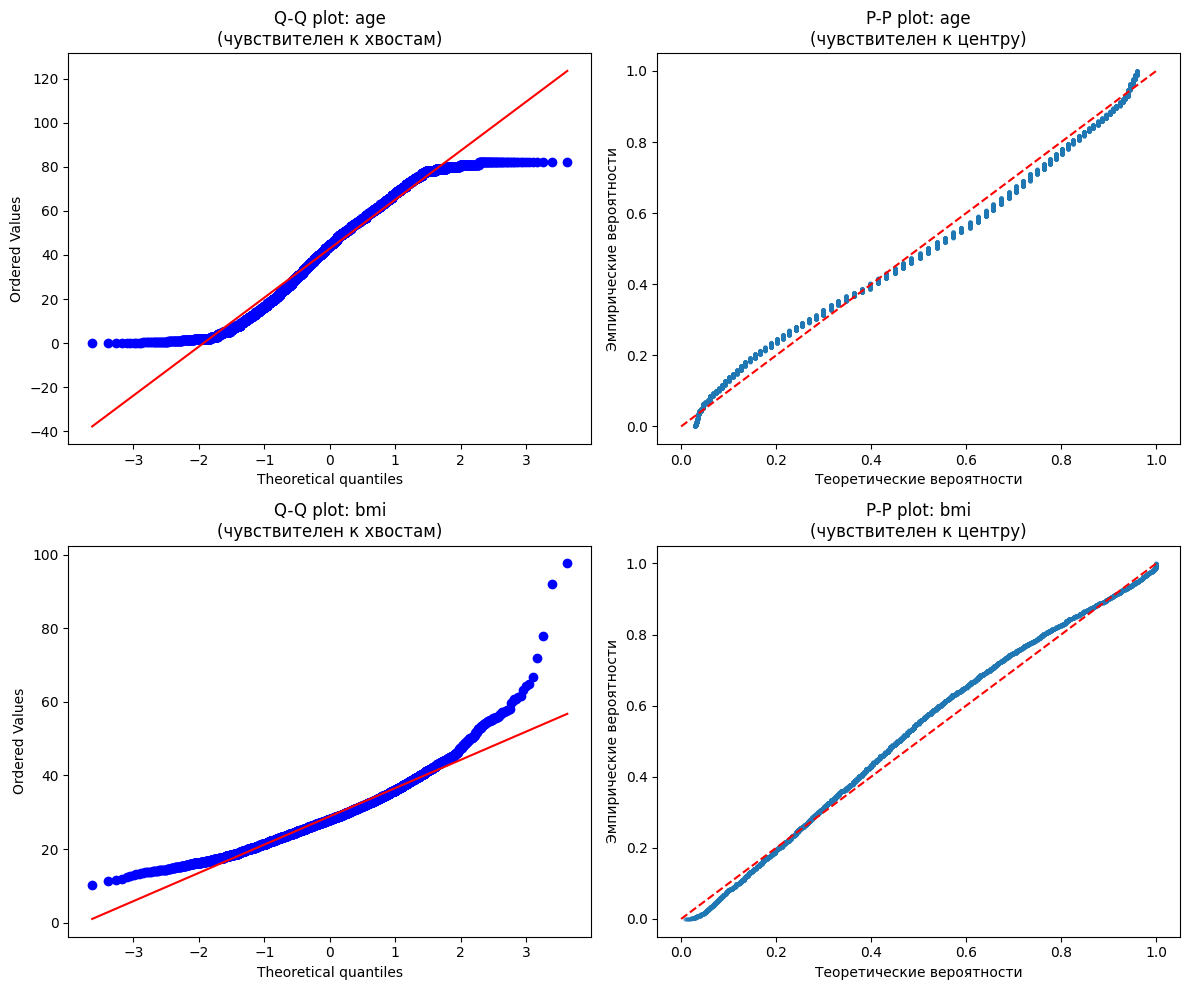


3. ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ:
   Q-Q plot: точки на прямой => нормальное распределение
   P-P plot: точки на диагонали => нормальное распределение
   S-образная форма на Q-Q plot => тяжелые хвосты (выбросы)
   Если p-value >= 0.05 И точки на диагонали/прямой => данные НОРМАЛЬНЫ


In [15]:
# P-P plot (Probability-Probability plot):
# - Сравнивает теоретические и эмпирические ВЕРОЯТНОСТИ
# - Ось X: теоретические вероятности (нормальное распределение)
# - Ось Y: эмпирические вероятности (фактические доли)
# - Если точки на диагонали (y=x) -> данные нормальны
# - Чувствителен к ОТКЛОНЕНИЯМ В ЦЕНТРЕ распределения

# Q-Q plot (Quantile-Quantile plot):
# - Сравнивает теоретические и эмпирические КВАНТИЛИ
# - Ось X: теоретические квантили (нормальное распределение)
# - Ось Y: эмпирические квантили (фактические значения)
# - Если точки на прямой линии -> данные нормальны
# - S-образная форма -> тяжелые хвосты (есть выбросы)
# - Чувствителен к ОТКЛОНЕНИЯМ НА ХВОСТАХ распределения

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Q-Q plot для age (чувствителен к хвостам)
stats.probplot(x, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q plot: age\n(чувствителен к хвостам)')

# P-P plot для age (чувствителен к центру)
sorted_x = np.sort(x)
n_x = len(sorted_x)
empirical_p_x = np.arange(1, n_x+1) / (n_x+1)
theoretical_p_x = stats.norm.cdf(sorted_x, loc=np.mean(x), scale=np.std(x, ddof=1))
axes[0, 1].scatter(theoretical_p_x, empirical_p_x, alpha=0.5, s=5)
axes[0, 1].plot([0, 1], [0, 1], 'r--')
axes[0, 1].set_xlabel('Теоретические вероятности')
axes[0, 1].set_ylabel('Эмпирические вероятности')
axes[0, 1].set_title('P-P plot: age\n(чувствителен к центру)')

# Q-Q plot для bmi
stats.probplot(y, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot: bmi\n(чувствителен к хвостам)')

# P-P plot для bmi
sorted_y = np.sort(y)
n_y = len(sorted_y)
empirical_p_y = np.arange(1, n_y+1) / (n_y+1)
theoretical_p_y = stats.norm.cdf(sorted_y, loc=np.mean(y), scale=np.std(y, ddof=1))
axes[1, 1].scatter(theoretical_p_y, empirical_p_y, alpha=0.5, s=5)
axes[1, 1].plot([0, 1], [0, 1], 'r--')
axes[1, 1].set_xlabel('Теоретические вероятности')
axes[1, 1].set_ylabel('Эмпирические вероятности')
axes[1, 1].set_title('P-P plot: bmi\n(чувствителен к центру)')

plt.tight_layout()
plt.show()


print("\n3. ИТОГОВАЯ ИНТЕРПРЕТАЦИЯ:")
print("   Q-Q plot: точки на прямой => нормальное распределение")
print("   P-P plot: точки на диагонали => нормальное распределение")
print("   S-образная форма на Q-Q plot => тяжелые хвосты (выбросы)")
print("   Если p-value >= 0.05 И точки на диагонали/прямой => данные НОРМАЛЬНЫ")

## *1.4 Сделать выводы о линейной зависимости независимой и зависимой переменной на основе вычисления коэффициента корреляции. Определите доверительные интервалы (процентильный и t-интервал) для коэффициента корреляции с помощью bootstrap метода.*
!!! В данном случае бутстрап выборки формируются их пар значений (x,y)

In [16]:

# x = age (независимая), y = bmi (зависимая)

x = df_clean['age'].values
y = df_clean['bmi'].values
n = len(x)
print(len(x) == len(y))  # True

# ЭТАП 1. КЛАССИФИКАЦИЯ ТИПА ДАННЫХ
print("\n1. КЛАССИФИКАЦИЯ ТИПА ДАННЫХ:")
print("   age: количественная (непрерывная)")
print("   bmi: количественная (непрерывная)")
print("   Для двух количественных переменных используем коэффициент корреляции Пирсона")

# ЭТАП 2. ПРОВЕРКА НОРМАЛЬНОСТИ (для выбора метода корреляции)
# критерий Колмогорова-Смирнова
# H0: распределение является нормальным
# H1: распределение не является нормальным
# Уровень значимости α = 0.05

print("\n2. ПРОВЕРКА НОРМАЛЬНОСТИ (для выбора метода корреляции)")

# Проверка нормальности для age
mu_age = np.mean(x)
sigma_age = np.std(x, ddof=1)
ks_age, p_age = stats.kstest(x, 'norm', args=(mu_age, sigma_age))
print(f"\nage:")
print(f"D_n = {ks_age:.4f}, p-value = {p_age:.6f}")
if p_age >= 0.05:
    print(f"{p_age:.6f} >= 0.05 => распределение НОРМАЛЬНОЕ")
    normal_age = True
else:
    print(f"{p_age:.6f} < 0.05 => распределение НЕ НОРМАЛЬНОЕ")
    normal_age = False

# Проверка нормальности для bmi
mu_bmi = np.mean(y)
sigma_bmi = np.std(y, ddof=1)
ks_bmi, p_bmi = stats.kstest(y, 'norm', args=(mu_bmi, sigma_bmi))
print(f"\nbmi:")
print(f"D_n = {ks_bmi:.4f}, p-value = {p_bmi:.6f}")
if p_bmi >= 0.05:
    print(f"{p_bmi:.6f} >= 0.05 => распределение НОРМАЛЬНОЕ")
    normal_bmi = True
else:
    print(f"{p_bmi:.6f} < 0.05 => распределение НЕ НОРМАЛЬНОЕ")
    normal_bmi = False

# Выбор коэффициента корреляции
if normal_age and normal_bmi:
    corr_method = "Пирсон (r)"
    use_pearson = True
    print(f"\n   ВЫВОД: обе переменные нормальны => используем коэффициент Пирсона")
else:
    corr_method = "Спирмен (r_s)"
    use_pearson = False
    print(f"\n   ВЫВОД: хотя бы одна переменная НЕ нормальна => используем коэффициент Спирмена")

#3. РАСЧЁТ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ И ПРОВЕРКА ГИПОТЕЗЫ

print("\n3. РАСЧЁТ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ И ПРОВЕРКА ГИПОТЕЗЫ")
print("H0: коэффициент корреляции = 0 (связи нет)")
print("H1: коэффициент корреляции != 0 (связь есть)")

if use_pearson:
    r, p_value = stats.pearsonr(x, y)
    method = "Пирсон"
    print(f"\n   Коэффициент корреляции Пирсона (r):")
else:
    r, p_value = stats.spearmanr(x, y)
    method = "Спирмен"
    print(f"\n   Коэффициент ранговой корреляции Спирмена (r_s):")

print(f"     {method}: {r:.4f}")
print(f"     p-value = {p_value:.6e}")

if p_value < 0.05:
    print(f"     {p_value:.6e} < 0.05 => H0 ОТВЕРГАЕТСЯ")
    print(f"     => Связь статистически ЗНАЧИМА")
    significant = True
else:
    print(f"     {p_value:.6f} >= 0.05 => H0 НЕ ОТВЕРГАЕТСЯ")
    print(f"     => Связь статистически НЕ ЗНАЧИМА")
    significant = False



True

1. КЛАССИФИКАЦИЯ ТИПА ДАННЫХ:
   age: количественная (непрерывная)
   bmi: количественная (непрерывная)
   Для двух количественных переменных используем коэффициент корреляции Пирсона

2. ПРОВЕРКА НОРМАЛЬНОСТИ (для выбора метода корреляции)

age:
D_n = 0.0501, p-value = 0.000000
0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ

bmi:
D_n = 0.0588, p-value = 0.000000
0.000000 < 0.05 => распределение НЕ НОРМАЛЬНОЕ

   ВЫВОД: хотя бы одна переменная НЕ нормальна => используем коэффициент Спирмена

3. РАСЧЁТ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ И ПРОВЕРКА ГИПОТЕЗЫ
H0: коэффициент корреляции = 0 (связи нет)
H1: коэффициент корреляции != 0 (связь есть)

   Коэффициент ранговой корреляции Спирмена (r_s):
     Спирмен: 0.3756
     p-value = 2.475966e-164
     2.475966e-164 < 0.05 => H0 ОТВЕРГАЕТСЯ
     => Связь статистически ЗНАЧИМА


In [17]:
# ЭТАП 4. ОЦЕНКА СИЛЫ И НАПРАВЛЕНИЯ СВЯЗИ
if significant:
    print("\n4. ОЦЕНКА СИЛЫ И НАПРАВЛЕНИЯ СВЯЗИ:")
    
    # Направление
    if r > 0:
        direction = "положительная (прямая)"
    else:
        direction = "отрицательная (обратная)"
    
    # Сила
    abs_r = abs(r)
    if abs_r < 0.2:
        strength = "очень слабая"
    elif abs_r < 0.5:
        strength = "слабая"
    elif abs_r < 0.7:
        strength = "средняя"
    elif abs_r < 0.9:
        strength = "высокая"
    else:
        strength = "очень высокая"
    
    print(f"   Направление: {direction}")
    print(f"   Сила связи: {strength} (|r| = {abs_r:.4f})")
    print(f"   Интерпретация: при увеличении возраста индекс массы тела {'растёт' if r > 0 else 'падает'}")


4. ОЦЕНКА СИЛЫ И НАПРАВЛЕНИЯ СВЯЗИ:
   Направление: положительная (прямая)
   Сила связи: слабая (|r| = 0.3756)
   Интерпретация: при увеличении возраста индекс массы тела растёт


In [18]:
# ЭТАП 5. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ (BOOTSTRAP)
print("\n5. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ (BOOTSTRAP):")
# Цель: оценить диапазон, в котором находится истинный коэффициент корреляции
# Метод: бутстрап выборки формируются из пар (x, y) с возвращением

B = 1000  # количество бутстрап-выборок
np.random.seed(42)  # для воспроизводимости

# БАЗОВЫЙ АЛГОРИТМ БУТСТРАПА (раздел 2.1):
# 1. Генерация бутстрап-выборок: из исходной выборки извлекаем n наблюдений с возвращением
# 2. Вычисление статистики на бутстрап-выборке
# 3. Повторение шагов 1-2 B раз (B=1000)
# 4. Получение эмпирического бутстрап-распределения статистики

# ШАГ 1: генерируем B наборов индексов (матрица B x n)
bootindices = np.random.choice(n, size=(B, n), replace=True)

# ШАГ 2: получаем бутстрап-выборки для x и y по одним и тем же индексам
xboot = x[bootindices]  # матрица B x n
yboot = y[bootindices]  # матрица B x n

# ШАГ 3: вычисляем коэффициент корреляции для каждой бутстрап-выборки
rboot = []      # значения r* (коэффициент корреляции на бутстрап-выборке)
seboot = []     # стандартные ошибки для каждой бутстрап-выборки (для t-интервала)

for i in range(B):
    if use_pearson:
        r_star = stats.pearsonr(xboot[i], yboot[i])[0]
    else:
        r_star = stats.spearmanr(xboot[i], yboot[i])[0]
    rboot.append(r_star)
    
    # стандартная ошибка для бутстрап-выборки (для t-интервала)
    # для корреляции Пирсона: SE(r*) ≈ (1 - r*²) / √(n-2)
    # для Спирмена используем ту же формулу как приближение
    se_star = (1 - r_star**2) / np.sqrt(n - 2)
    seboot.append(se_star)

rboot = np.array(rboot)
seboot = np.array(seboot)

# 5.1 ПРОЦЕНТИЛЬНЫЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (раздел 2.2.1)
print("\n   5.1. Процентильный доверительный интервал (95%):")
# Формула: CI_perc = (θ̂*_(α/2), θ̂*_(1-α/2))

cilower = np.percentile(rboot, 2.5)   # 2.5-й процентиль = θ̂*_(α/2) при α=0.05
ciupper = np.percentile(rboot, 97.5)  # 97.5-й процентиль = θ̂*_(1-α/2)

print(f"     Нижняя граница (2.5-й процентиль): {cilower:.4f}")
print(f"     Верхняя граница (97.5-й процентиль): {ciupper:.4f}")
print(f"     95% ДИ = ({cilower:.4f}, {ciupper:.4f})")

if cilower > 0:
    print(f"     Доверительный интервал (ДИ) НЕ содержит 0 => связь положительная и значимая")
elif ciupper < 0:
    print(f"     ДИ НЕ содержит 0 => связь отрицательная и значимая")
else:
    print(f"     ДИ содержит 0 => связь НЕ значима (подтверждает p-value)")

# 5.2 T-ИНТЕРВАЛ (СТЬЮДЕНТИЗИРОВАННЫЙ, раздел 2.2.2)
print("\n   5.2. T-интервал (стьюдентизированный) 95% ДИ:")

# ШАГ 1: вычисляем T* = (θ̂* - θ̂) / SE* для каждой бутстрап-выборки
# T* = (r* - r) / SE*
t_star = (rboot - r) / seboot

# ШАГ 2: находим квантили T* для α/2 = 2.5% и 1-α/2 = 97.5%
t_lower = np.percentile(t_star, 2.5)
t_upper = np.percentile(t_star, 97.5)

# ШАГ 3: стандартная ошибка исходной оценки SE(θ̂)
# для коэффициента корреляции: SE(r) ≈ (1 - r²) / √(n-2)
se_original = (1 - r**2) / np.sqrt(n - 2)

# ШАГ 4: формула доверительного интервала:
# CI = (θ̂ - t*_(1-α/2)·SE(θ̂), θ̂ - t*_(α/2)·SE(θ̂))
cilower_t = r - t_upper * se_original
ciupper_t = r - t_lower * se_original

print(f"     T* статистики: нижний 2.5% квантиль = {t_lower:.4f}, верхний 97.5% = {t_upper:.4f}")
print(f"     Стандартная ошибка SE = {se_original:.4f}")
print(f"     95% ДИ = ({cilower_t:.4f}, {ciupper_t:.4f})")

# Сравнение интервалов
print("\n   5.3. Сравнение доверительных интервалов:")
print(f"     Процентильный: ({cilower:.4f}, {ciupper:.4f})")
print(f"     T-интервал:    ({cilower_t:.4f}, {ciupper_t:.4f})")

# ЭТАП 6. ИТОГОВЫЙ ВЫВОД
print("\n6. ИТОГОВЫЙ ВЫВОД О ЛИНЕЙНОЙ ЗАВИСИМОСТИ:")
print(f"   Переменные: age и bmi")
print(f"   Коэффициент корреляции ({method}): {r:.4f}")

if significant:
    print(f"   p-value = {p_value:.6e} < 0.05 => связь статистически значима")
    print(f"   Характер связи: {strength}, {direction}")
    print(f"   95% доверительный интервал (процентильный): ({cilower:.4f}, {ciupper:.4f})")
    print(f"   95% доверительный интервал (t-интервал): ({cilower_t:.4f}, {ciupper_t:.4f})")
    if cilower > 0 or ciupper < 0:
        print(f"\n   {cilower:.4f} > 0 or {ciupper:.4f} < 0 => Доверительные интервалы не содержат 0, что подтверждает значимость связи")
else:
    print(f"\n   p-value = {p_value:.6f} >= 0.05 -> связь статистически не значима")
    print(f"   => Индекс массы тела НЕ зависит от возраста")


5. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ (BOOTSTRAP):



   5.1. Процентильный доверительный интервал (95%):
     Нижняя граница (2.5-й процентиль): 0.3496
     Верхняя граница (97.5-й процентиль): 0.4016
     95% ДИ = (0.3496, 0.4016)
     Доверительный интервал (ДИ) НЕ содержит 0 => связь положительная и значимая

   5.2. T-интервал (стьюдентизированный) 95% ДИ:
     T* статистики: нижний 2.5% квантиль = -2.0778, верхний 97.5% = 2.1683
     Стандартная ошибка SE = 0.0123
     95% ДИ = (0.3491, 0.4011)

   5.3. Сравнение доверительных интервалов:
     Процентильный: (0.3496, 0.4016)
     T-интервал:    (0.3491, 0.4011)

6. ИТОГОВЫЙ ВЫВОД О ЛИНЕЙНОЙ ЗАВИСИМОСТИ:
   Переменные: age и bmi
   Коэффициент корреляции (Спирмен): 0.3756
   p-value = 2.475966e-164 < 0.05 => связь статистически значима
   Характер связи: слабая, положительная (прямая)
   95% доверительный интервал (процентильный): (0.3496, 0.4016)
   95% доверительный интервал (t-интервал): (0.3491, 0.4011)

   0.3496 > 0 or 0.4016 < 0 => Доверительные интервалы не содержат 0, что п

## *1.5 Построить линейное и полиномиальное уравнения регрессии. Регрессионный анализ провести с помощью библиотек:*
- *statsmodels,*
- *sklearn.*    
*Понимать, какие данные выводятся встроенными методами регрессионного анализа для
каждой их библиотек.*
*Например, результаты регрессионного анализа с помощью библиотеки statsmodels будут
представлены в виде таблицы (таб. 1). Для выделенных переменных понимать, что они
означают, и уметь получать их значения самостоятельно.*

#### РЕГРЕССИОННЫЙ АНАЛИЗ (ЛИНЕЙНАЯ И ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ)

ЦЕЛЬ: построить модель, описывающую зависимость переменной Y (charges) от переменной X (age или bmi), и оценить качество этой модели.

ДВА ПОДХОДА К ПОСТРОЕНИЮ РЕГРЕССИИ:

1. statsmodel — подробный статистический вывод (p-value, R^2, F-статистика)
2. sklearn — предсказания и метрики качества (MSE, MAE, R^2)

ЛИНЕЙНАЯ РЕГРЕССИЯ:

Формула модели:
$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

где:
- y — зависимая переменная (отклик, charges)
- x — независимая переменная (предиктор, age или bmi)
- $\beta_0$ — intercept (свободный член, значение y при x=0)
- $\beta_1$ — slope (коэффициент наклона, изменение y при изменении x на 1)
- epsilon — случайная ошибка (остаток)

ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ 2-Й СТЕПЕНИ:

Формула модели:
$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \varepsilon
$$

где добавляется квадратичный член x^2 для учёта нелинейных зависимостей.

РЕЗУЛЬТАТЫ STATSMODEL (TAB. 1):

| Показатель | Обозначение | Что означает |
|------------|-------------|---------------|
| Dep. Variable | Y | Зависимая переменная |
| R-squared | R^2 | Коэффициент детерминации (доля объяснённой дисперсии) |
| Adj. R-squared | R^2_adj | Скорректированный R^2 (с учётом числа предикторов) |
| F-statistic | F | Статистика Фишера (значимость модели целиком) |
| Prob (F-statistic) | p-value | Вероятность ошибки для F-статистики |
| coef | beta | Коэффициент регрессии |
| std err | SE | Стандартная ошибка коэффициента |
| t | t-статистика | t = coef / std err |
| P>|t| | p-value для коэффициента (значимость влияния) |
| [0.025, 0.975] | | 95% доверительный интервал для коэффициента |
| Omnibus | | Тест на нормальность остатков |
| Durbin-Watson | | Тест на автокорреляцию остатков |
| AIC / BIC | | Информационные критерии (сравнение моделей) |

КЛЮЧЕВЫЕ ВЫВОДЫ ИЗ ТАБЛИЦЫ STATSMODEL:

1. R^2 (0.09) → модель объясняет 9% изменчивости Y (чем ближе к 1, тем лучше)
2. Prob (F-statistic) < 0.05 → модель статистически значима
3. P>|t| для beta_1 < 0.05 → переменная X значимо влияет на Y
4. Если P>|t| для beta_2 < 0.05 → квадратичный член значим (есть нелинейность)

РЕЗУЛЬТАТЫ SKLEARN (МЕТРИКИ КАЧЕСТВА):

| Метрика | Формула | Что означает |
|---------|---------|---------------|
| R² score | 1 - (SS_res / SS_tot) | Доля объяснённой дисперсии (чем ближе к 1, тем лучше) |
| MSE | (1/n) * сумма(y_i - y_i(с крышечкой))^2 | Среднеквадратичная ошибка (чем меньше, тем лучше) |
| MAE | (1/n) * сумма|y_i - y_i(с крышечкой)| | Средняя абсолютная ошибка (чем меньше, тем лучше) |
| RMSE | √MSE | Корень из MSE (в единицах измерения Y) |


In [19]:
#python -m pip install scikit-learn
# 1.5.1 Линейная регрессия с помощью statsmodels

import statsmodels.api as sm

# Добавляем константу (свободный член a)
# Формула: X = [1, x] для модели y = a + b*x
X_sm = sm.add_constant(x)  # X_sm[:,0] = 1 (константа), X_sm[:,1] = age

# Оценка параметров методом наименьших квадратов (МНК)
# Формула МНК: Ф = sum(y_i - (a + b*x_i))^2 -> min
model_sm = sm.OLS(y, X_sm).fit()  # OLS = Ordinary Least Squares

print("\nРезультаты регрессионного анализа (statsmodels):")
print(model_sm.summary())  # Выводит полную таблицу с R^2, p-value, F-статистикой

# Извлечение основных параметров
a_sm = model_sm.params[0]  # intercept (свободный член a) - значение y при x=0
b_sm = model_sm.params[1]  # slope (коэффициент наклона b) - изменение y при dx=1

print(f"\nУравнение линейной регрессии: bmi = {a_sm:.4f} + {b_sm:.4f} * age")

# Доверительные интервалы для параметров (95%)
# Формула: a_hat +- t_{alpha/2, n-2} * SE(a_hat)
conf_int = model_sm.conf_int(alpha=0.05)  # alpha=0.05 -> 95% ДИ
print(f"\n95%% доверительные интервалы для параметров:")
print(f"  a (intercept): ({conf_int[0,0]:.4f}, {conf_int[0,1]:.4f})")
print(f"  b (age):       ({conf_int[1,0]:.4f}, {conf_int[1,1]:.4f})")

# Проверка значимости коэффициентов (t-критерий Стьюдента)
# H0: b = 0 (коэффициент не значим)
# H1: b != 0 (коэффициент значим)
# Формула t = b_hat / SE(b_hat)
print(f"\nПроверка значимости коэффициентов:")
print(f"  Коэффициент b: t = {model_sm.tvalues[1]:.4f}, p-value = {model_sm.pvalues[1]:.4e}")
if model_sm.pvalues[1] < 0.05:
    print(f"    Коэффициент b значим (p-value < 0.05), возраст влияет на BMI")
else:
    print(f"    Коэффициент b незначим (p-value >= 0.05)")

# Оценка качества модели
# R^2 = SSR/SST = 1 - SSE/SST (доля объясненной дисперсии)
# adj.R^2 = 1 - (1-R^2)*(n-1)/(n-l-1) (штраф за количество параметров)
print(f"\nОценка качества модели:")
print(f"  R^2 = {model_sm.rsquared:.4f}")
print(f"  Adj. R^2 = {model_sm.rsquared_adj:.4f}")
print(f"  F-статистика = {model_sm.fvalue:.4f}, p-value = {model_sm.f_pvalue:.4e}")

# Проверка значимости модели целиком (критерий Фишера)
# H0: все коэффициенты = 0 (модель не значима)
# H1: хотя бы один коэффициент != 0 (модель значима)
if model_sm.f_pvalue < 0.05:
    print(f"  Модель значима (p-value < 0.05)")
else:
    print(f"  Модель незначима (p-value >= 0.05)")



Результаты регрессионного анализа (statsmodels):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     613.6
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          9.52e-128
Time:                        16:36:18   Log-Likelihood:                -16793.
No. Observations:                4909   AIC:                         3.359e+04
Df Residuals:                    4907   BIC:                         3.360e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [20]:
import numpy as np
import statsmodels.api as sm

print("\n1.5.4 Полиномиальная регрессия (степень 2) с помощью statsmodels")

# 1. Формируем матрицу признаков вручную
# Столбец 1: сам возраст (age), Столбец 2: возраст в квадрате (age^2)
# Предполагаем, что x — это одномерный массив с возрастом (age)
X_poly_manual = np.column_stack((x, x**2))

# 2. Обязательно добавляем константу (свободный член a) для statsmodels
X_poly_sm = sm.add_constant(X_poly_manual)

# 3. Обучаем модель методом наименьших квадратов (OLS)
# Помните: в statsmodels сначала передается Y (bmi), затем X
model_poly_sm_fit = sm.OLS(y, X_poly_sm).fit()

# 4. Выводим полную статистическую таблицу (Таб. 1 из методички)
print(model_poly_sm_fit.summary())

# 5. Извлекаем коэффициенты уравнения
# В params[0] будет const (свободный член a)
# В params[1] будет x1 (коэффициент при линейном age)
# В params[2] будет x2 (коэффициент при квадратичном age^2)
a_poly_sm = model_poly_sm_fit.params[0]
b1_poly_sm = model_poly_sm_fit.params[1]
b2_poly_sm = model_poly_sm_fit.params[2]

print(f"Уравнение полиномиальной регрессии (statsmodels):")
print(f"  bmi = {a_poly_sm:.4f} + {b1_poly_sm:.4f} * age + {b2_poly_sm:.4f} * age^2")

# 6. Извлекаем метрики качества
r2_poly_sm = model_poly_sm_fit.rsquared          # R²
adj_r2_poly_sm = model_poly_sm_fit.rsquared_adj  # Скорректированный R²
rmse_poly_sm = np.sqrt(model_poly_sm_fit.mse_resid) # RMSE


print(f"\nМетрики качества полиномиальной модели (statsmodels):")
print(f"  R^2 = {r2_poly_sm:.4f}")
print(f"  Adjusted R^2 = {adj_r2_poly_sm:.4f}")
#print(f"  F-статистика = {model_sm.fvalue:.4f}, p-value = {model_sm.f_pvalue:.4e}")
print(f"  RMSE = {rmse_poly_sm:.4f}")


1.5.4 Полиномиальная регрессия (степень 2) с помощью statsmodels
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     776.3
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          1.18e-293
Time:                        16:36:18   Log-Likelihood:                -16408.
No. Observations:                4909   AIC:                         3.282e+04
Df Residuals:                    4906   BIC:                         3.284e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [21]:
# 1.5.2 Линейная регрессия с помощью sklearn

print("\n1.5.2 Линейная регрессия (sklearn)")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# sklearn требует двумерный массив для признаков
X_sk = x.reshape(-1, 1)  # преобразуем из (n,) в (n,1) - столбец

# Создание и обучение модели
# МНК: находит a и b, минимизирующие sum(y_i - (a + b*x_i))^2
model_sk = LinearRegression()
model_sk.fit(X_sk, y)  # fit - обучение модели на данных

a_sk = model_sk.intercept_  # свободный член (a)
b_sk = model_sk.coef_[0]    # коэффициент наклона (b)

print(f"Уравнение линейной регрессии: bmi = {a_sk:.4f} + {b_sk:.4f} * age")
print(f"  (сравнение со statsmodels: bmi = {a_sm:.4f} + {b_sm:.4f} * age)")

# Предсказания: y_hat = a + b*x
y_pred_sk = model_sk.predict(X_sk)

# Метрики качества
# R^2 = 1 - sum(y_i - y_hat_i)^2 / sum(y_i - y_mean)^2
r2_sk = r2_score(y, y_pred_sk)
# RMSE = sqrt(MSE) = sqrt( (1/n) * sum(y_i - y_hat_i)^2 )
rmse_sk = np.sqrt(mean_squared_error(y, y_pred_sk))

print(f"\nМетрики качества (sklearn):")
print(f"  R^2 = {r2_sk:.4f}")
print(f"  RMSE = {rmse_sk:.4f}")


1.5.2 Линейная регрессия (sklearn)


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# 1.5.3 Полиномиальная регрессия (степень 2) с помощью sklearn

print("\n1.5.3 Полиномиальная регрессия (степень 2) с помощью sklearn")

from sklearn.preprocessing import PolynomialFeatures

# Создание полиномиальных признаков: [x] -> [x, x^2]
# Формула модели: y = a + b1*x + b2*x^2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_sk)  # X_poly[:,0] = age, X_poly[:,1] = age^2

# Обучение полиномиальной модели (МНК для множественной регрессии)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# Коэффициенты модели
b1_poly = model_poly.coef_[0]  # коэффициент при age (линейный член)
b2_poly = model_poly.coef_[1]  # коэффициент при age^2 (квадратичный член)
a_poly = model_poly.intercept_  # свободный член

print(f"Уравнение полиномиальной регрессии (степень 2):")
print(f"  bmi = {a_poly:.4f} + {b1_poly:.4f} * age + {b2_poly:.4f} * age^2")

# Предсказания: y_hat = a + b1*x + b2*x^2
y_pred_poly = model_poly.predict(X_poly)

# Метрики качества
r2_poly = r2_score(y, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print(f"\nМетрики качества полиномиальной модели (степень 2):")
print(f"  R^2 = {r2_poly:.4f}")
print(f"  RMSE = {rmse_poly:.4f}")


1.5.3 Полиномиальная регрессия (степень 2) с помощью sklearn
Уравнение полиномиальной регрессии (степень 2):
  bmi = 17.1711 + 0.5776 * age + -0.0056 * age^2

Метрики качества полиномиальной модели (степень 2):
  R^2 = 0.2404
  RMSE = 6.8445


In [ ]:
# 1.5.4 Сравнение качества линейной и полиномиальной моделей

print("\n1.5.4 Сравнение качества моделей")
print(f"{'Модель':<25} {'R^2':<10} {'RMSE':<10}")
print(f"{'Линейная регрессия':<25} {r2_sk:.4f}       {rmse_sk:.4f}")
print(f"{'Полиномиальная (степень 2)':<25} {r2_poly:.4f}       {rmse_poly:.4f}")

# Улучшение качества при добавлении полиномиального члена
r2_improvement = r2_poly - r2_sk
rmse_improvement = rmse_sk - rmse_poly

print(f"\nУлучшение при использовании полиномиальной модели:")
print(f"  R^2 увеличился на {r2_improvement:.4f} ({r2_improvement/r2_sk*100:.2f}%)")
print(f"  RMSE уменьшился на {rmse_improvement:.4f} ({rmse_improvement/rmse_sk*100:.2f}%)")




1.5.4 Сравнение качества моделей
Модель                    R^2        RMSE      


NameError: name 'r2_sk' is not defined

## *1.6 Количественно сравнить качество полученных линейной и полиномиальной регрессионных моделей.*
Для оценки качества регрессионной модели в презентации используются две основные метрики: **R² (коэффициент детерминации)** и **скорректированный R² (adj. R²)**.

#### Различные виды вариаций (суммы квадратов отклонений)

Из презентации:

| Обозначение | Название | Формула | Что характеризует |
|-------------|----------|---------|-------------------|
| **SST** (Sum of Square Total) | Общая вариация | сумма(y_i - ȳ):2 | Случайную ошибку для всей выборки, несоответствие между текущими значениями и средним арифметическим |
| **SSR** (Sum of Square Regression) | Вариация регрессии (фактора) | сумма(ŷ_i - ȳ)^2 | Часть вариации, объяснённую моделью |
| **SSE** (Sum of Square Error) | Вариация ошибок (остатков) | сумма(y_i - ŷ_i)^2 | Ошибку, с которой уравнение регрессии предсказывает фактический результат |

**Основное соотношение:**
```
SST = SSE + SSR
```
Общая сумма квадратов = «необъяснённая» сумма квадратов + «объяснённая» сумма квадратов

#### Коэффициент детерминации R^2

R² показывает долю дисперсии зависимой переменной, объяснённую моделью:

```
R² = SSR / SST = SSR / (SSR + SSE)
```

**Свойства:**
- R² ∈ [0, 1]
- Чем меньше SSE, тем ближе R^2 к 1, тем лучше модель описывает данные
- R² = 1 означает, что модель объясняет 100% дисперсии (все точки лежат на линии регрессии)
- R² = 0 означает, что модель не объясняет дисперсию (горизонтальная линия на уровне среднего)

#### Проблема R^2

Проблема использования R² заключается в том, что **его значение не уменьшается при добавлении в уравнение факторов, сколь плохи бы они ни были**. R² гарантированно будет равен 1, если добавить в модель столько факторов, сколько у нас наблюдений. Поэтому сравнивать модели с разным количеством факторов, используя R², не имеет смысла.

#### Скорректированный коэффициент детерминации adj. R^2

Для более адекватной оценки модели используется скорректированный коэффициент детерминации, который накладывает **«штраф» за каждый добавленный фактор**:

```
adj.R² = 1 - (1 - R²) × (N - 1) / (N - l + 1)
```

где:
- **N** — количество наблюдений
- **l** — количество параметров в регрессионной модели

Для линейной модели: l = 2 (свободный член a и коэффициент b)
Для полиномиальной модели степени 2: l = 3 (свободный член a, коэффициент при age, коэффициент при age²)

**Как сравнивать модели:**
- Модель с **более высоким adj. R²** считается лучше, так как она объясняет большую долю дисперсии с учётом штрафа за количество параметров
- Если adj. R^2 полиномиальной модели выше, чем у линейной, то добавление квадратичного члена оправдано
- Если adj. R^2 полиномиальной модели ниже или незначительно выше, то линейная модель предпочтительнее (она проще)


In [ ]:
print("\n1.6 Количественное сравнение качества линейной и полиномиальной регрессионных моделей")

print("\n1.6.1 Метрики качества")

n = len(y)  # количество наблюдений

# Для линейной модели (l = 2 параметра: a и b)
SSE_linear = np.sum((y - y_pred_sk)**2)  # сумма квадратов ошибок
SST_linear = np.sum((y - np.mean(y))**2)  # общая сумма квадратов
SSR_linear = SST_linear - SSE_linear  # сумма квадратов регрессии

R2_linear = SSR_linear / SST_linear  # коэффициент детерминации
adj_R2_linear = 1 - (1 - R2_linear) * (n - 1) / (n - 2)  # скорректированный R^2 (l=2)

# Для полиномиальной модели (l = 3 параметра: a, b1, b2)
SSE_poly = np.sum((y - y_pred_poly)**2)
SST_poly = np.sum((y - np.mean(y))**2)
SSR_poly = SST_poly - SSE_poly

R2_poly = SSR_poly / SST_poly
adj_R2_poly = 1 - (1 - R2_poly) * (n - 1) / (n - 3)  # скорректированный R^2 (l=3)

print("\nРезультаты расчёта") # (по формулам из презентации, слайды 13-14)
print(f"\n{'Показатель':<25} {'Линейная модель':<20} {'Полиномиальная модель (степень 2)':<30}")
print(f"{'SST (общая вариация)':<25} {SST_linear:<20.2f} {SST_poly:<30.2f}")
print(f"{'SSR (объяснённая вариация)':<25} {SSR_linear:<20.2f} {SSR_poly:<30.2f}")
print(f"{'SSE (необъяснённая вариация)':<25} {SSE_linear:<20.2f} {SSE_poly:<30.2f}")
print(f"{'R² (коэффициент детерминации)':<25} {R2_linear:<20.6f} {R2_poly:<30.6f}")
print(f"{'adj. R² (скорректированный)':<25} {adj_R2_linear:<20.6f} {adj_R2_poly:<30.6f}")

print("\nИнтерпретация") # (по презентации, слайд 14)
print("R^2 = SSR / SST = доля объяснённой дисперсии")
print(f"  Линейная модель объясняет {R2_linear*100:.2f}% дисперсии BMI")
print(f"  Полиномиальная модель объясняет {R2_poly*100:.2f}% дисперсии BMI")

print("\nСравнение моделей")
if adj_R2_poly > adj_R2_linear:
    improvement = (adj_R2_poly - adj_R2_linear) / abs(adj_R2_linear) * 100
    print(f"  Полиномиальная модель имеет БОЛЕЕ ВЫСОКИЙ скорректированный R²")
    print(f"  adj. R^2 вырос на {adj_R2_poly - adj_R2_linear:.6f} ({improvement:.2f}%)")
    print("  => Добавление квадратичного члена оправдано")
    print("  => Полиномиальная модель лучше описывает данные")
else:
    print(f"  Полиномиальная модель НЕ ЛУЧШЕ линейной (скорректированный R² не выше)")
    print("  => Линейная модель предпочтительнее (она проще, а качество не хуже)")

print("\nПроверка соотношения SST = SSR + SSE ") # (слайд 13)
print(f"  Линейная модель: SSR + SSE = {SSR_linear + SSE_linear:.2f}, SST = {SST_linear:.2f}")
print(f"  Полиномиальная модель: SSR + SSE = {SSR_poly + SSE_poly:.2f}, SST = {SST_poly:.2f}")


1.6 Количественное сравнение качества линейной и полиномиальной регрессионных моделей

1.6.1 Метрики качества


NameError: name 'y_pred_sk' is not defined

## *1.7. Построить график уравнений линейной и полиномиальной регрессии совместно с диаграммой рассеяния.*
1.7 ГРАФИК ЛИНЕЙНОЙ И ПОЛИНОМИАЛЬНОЙ РЕГРЕССИИ С ДИАГРАММОЙ РАССЕЯНИЯ

ТЕОРИЯ (по презентации, слайды 1, 5, 9):

1. ДИАГРАММА РАССЕЯНИЯ (SCATTER PLOT)

Диаграмма рассеяния — это графическое представление связи между двумя переменными.
Каждая точка на графике соответствует одному наблюдению с координатами (x, y).

По конфигурации точек можно определить:
- Направление связи (положительная или отрицательная)
- Силу связи (насколько точки сгруппированы)
- Форму связи (линейная или нелинейная)

2. ЛИНИЯ РЕГРЕССИИ

Линия регрессии — это графическое представление уравнения регрессии.
Она показывает предсказанные значения модели при разных значениях x.

Для линейной регрессии:
$$
\hat{y} = a + bx
$$
График — прямая линия.

Для полиномиальной регрессии 2-й степени:
$$
\hat{y} = a + b_1x + b_2x^2
$$
График — парабола (кривая).

3. СРАВНЕНИЕ МОДЕЛЕЙ НА ОДНОМ ГРАФИКЕ

Совместное отображение двух линий регрессии на одном графике позволяет:
- Визуально сравнить, какая модель лучше аппроксимирует данные
- Оценить, есть ли нелинейная зависимость
- Сделать предварительный вывод о качестве моделей

Правила интерпретации:

| Что видно на графике | Вывод |
|----------------------|-------|
| Красная кривая повторяет синюю прямую | Квадратичный член незначим, линейная модель достаточна |
| Красная кривая明显 изгибается и ближе к точкам | Есть нелинейная зависимость, полиномиальная модель лучше |
| Обе линии далеко от точек | Модели плохо описывают данные |

4. КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ R² НА ГРАФИКЕ

R² показывает долю дисперсии, объяснённую моделью:
- R² = 0.09 → модель объясняет 9% дисперсии
- Чем ближе R² к 1, тем лучше модель
- R² позволяет сравнить модели количественно

Формула:
$$
R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}
$$

5. ВИЗУАЛЬНАЯ ИНТЕРПРЕТАЦИЯ

- Если R² полиномиальной модели больше, чем у линейной, и кривая明显 ближе к точкам → полиномиальная модель предпочтительнее
- Если R² отличаются незначительно и кривая почти повторяет прямую → линейная модель достаточна (она проще)
- Если R² очень маленький (< 0.1) у обеих моделей → фактор x слабо влияет на y

In [ ]:
# 1.7 График линейной и полиномиальной регрессии совместно с диаграммой рассеяния

# ТЕОРИЯ:
# 1. Диаграмма рассеяния (scatter plot) - показывает исходные данные (x, y)
# 2. Линия регрессии - показывает предсказанные значения модели
# 3. Сравнение двух линий на одном графике позволяет визуально оценить,
#    какая модель лучше аппроксимирует данные

# Сортируем данные для построения плавных линий
idx = np.argsort(x)           # получаем индексы для сортировки x по возрастанию
x_sorted = x[idx]             # сортируем x

# Предсказания для отсортированных данных
y_linear = model_sk.predict(x_sorted.reshape(-1, 1))      # линейная модель
y_poly = model_poly.predict(poly.transform(x_sorted.reshape(-1, 1)))  # полиномиальная

# Построение графика
plt.figure(figsize=(12, 7))

# Диаграмма рассеяния (исходные данные)
plt.scatter(x, y, alpha=0.3, s=10, color='gray', label='Исходные данные')

# Линия линейной регрессии
plt.plot(x_sorted, y_linear, 'b-', linewidth=2, 
         label=f'Линейная регрессия: bmi = {a_sk:.2f} + {b_sk:.2f}·age\n(R² = {R2_linear:.4f})')

# Линия полиномиальной регрессии
plt.plot(x_sorted, y_poly, 'r-', linewidth=2,
         label=f'Полиномиальная регрессия (степень 2):\nbmi = {a_poly:.2f} + {b1_poly:.2f}·age + {b2_poly:.6f}·age²\n(R² = {R2_poly:.4f})')

# Настройка графика
plt.xlabel('Возраст (age)', fontsize=12)
plt.ylabel('Индекс массы тела (bmi)', fontsize=12)
plt.title('Сравнение линейной и полиномиальной регрессии (степень 2)', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ИНТЕРПРЕТАЦИЯ:
# - Синяя прямая = линейная модель (bmi = a + b·age)
# - Красная кривая = полиномиальная модель (bmi = a + b₁·age + b₂·age²)
# - Если кривая повторяет прямую → квадратичный член незначим
# - Если кривая изгибается → есть нелинейная зависимость

NameError: name 'model_sk' is not defined

## Логистическая регрессия: влияние возраста на гипертензию

---

## 2.1 Подготовка данных

Подготовка данных для логистической регрессии аналогична подготовке для обычной регрессии, но с одним важным отличием: **зависимая переменная должна быть категориальной** (обычно бинарной — 0 или 1).

**Что нужно сделать:**
1. **Выбрать переменные** — количественную (независимую) и категориальную (зависимую)
2. **Проверить пропуски** — удалить строки с `NaN`
3. **Проверить баланс классов** — сколько наблюдений в каждом классе (0 и 1)

**Зависимая (категориальная) переменная должна иметь ровно два исхода, которые кодируются как:**

- **1** — интересующее нас событие («Успех», «Да», «Заболел», «Купил»).
- **0** — противоположный исход («Разделяющий класс», «Нет», «Здоров», «Не купил»).

Независимая переменная в данном случае является **количественной** (непрерывной или дискретной)

**Почему важен баланс классов:**
- Если один класс встречается намного чаще другого (например, 95% vs 5%), модель может "выучиться" всегда предсказывать большинство и показывать высокую точность, но при этом не уметь находить редкий класс
- В таких случаях применяют специальные методы: взвешивание классов, oversampling, undersampling

**Что такое бинарная категориальная переменная:**
- Принимает только два значения (обычно 0 и 1)
- 0 — отсутствие признака (нет гипертензии)
- 1 — наличие признака (есть гипертензия)

---


In [22]:
# Выбираем пару переменных:
# Количественная: age (возраст)
# Категориальная (бинарная): hypertension (гипертензия: 0 - нет, 1 - есть)

print("\nВыбранные переменные:")
print("  - Количественная (независимая): age (возраст пациента)")
print("  - Категориальная (зависимая): hypertension (наличие гипертензии: 0=нет, 1=да)")
print("  - Цель: предсказать вероятность гипертензии на основе возраста")

# 2.1 Подготовка данных
print("\n2.1 Подготовка данных")

# Выбираем нужные переменные
df_task2 = df[['age', 'hypertension']].copy()

# Проверка на пропуски
print(f"Исходное количество записей: {len(df_task2)}")
print(f"Пропущенные значения в age: {df_task2['age'].isnull().sum()}")
print(f"Пропущенные значения в hypertension: {df_task2['hypertension'].isnull().sum()}")

# Удаление пропущенных значений (если есть)
df_task2 = df_task2.dropna()
print(f"Количество записей после очистки: {len(df_task2)}")

# Проверка распределения категориальной переменной
print("\nРаспределение целевой переменной (hypertension):")
hypertension_counts = df_task2['hypertension'].value_counts()
print(f"  0 (нет гипертензии): {hypertension_counts.get(0, 0)} записей ({hypertension_counts.get(0, 0)/len(df_task2)*100:.2f}%)")
print(f"  1 (есть гипертензия): {hypertension_counts.get(1, 0)} записей ({hypertension_counts.get(1, 0)/len(df_task2)*100:.2f}%)")




Выбранные переменные:
  - Количественная (независимая): age (возраст пациента)
  - Категориальная (зависимая): hypertension (наличие гипертензии: 0=нет, 1=да)
  - Цель: предсказать вероятность гипертензии на основе возраста

2.1 Подготовка данных
Исходное количество записей: 5110
Пропущенные значения в age: 0
Пропущенные значения в hypertension: 0
Количество записей после очистки: 5110

Распределение целевой переменной (hypertension):
  0 (нет гипертензии): 4612 записей (90.25%)
  1 (есть гипертензия): 498 записей (9.75%)


## 2.2. Визуализация данных

### Теория

Для анализа связи количественной и бинарной категориальной переменной используются специальные виды визуализации:

| Тип графика | Что показывает | Как интерпретировать |
|-------------|----------------|----------------------|
| **Гистограммы с разделением по классам** | Распределение количественной переменной для каждого класса | Если распределения сильно отличаются (смещены друг относительно друга) → переменная хорошо разделяет классы |
| **Коробчатые диаграммы (boxplot)** | Медиану и квартили количественной переменной для каждого класса | Если медианы заметно различаются → вероятна связь |
| **Диаграмма рассеяния с jitter** | Значения количественной переменной для каждого класса с добавлением случайного шума по вертикали | jitter нужен, чтобы точки не накладывались друг на друга (иначе будут только две горизонтальные линии) |

**Jitter (джиттер)** — это добавление небольшого случайного шума к значениям категориальной переменной, чтобы разнести точки по вертикали и увидеть их плотность.

---

C:\Users\Angel\AppData\Local\Temp\ipykernel_18448\3411043078.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(data_by_hypertension, labels=['Нет гипертензии (0)', 'Есть гипертензия (1)'], patch_artist=True)


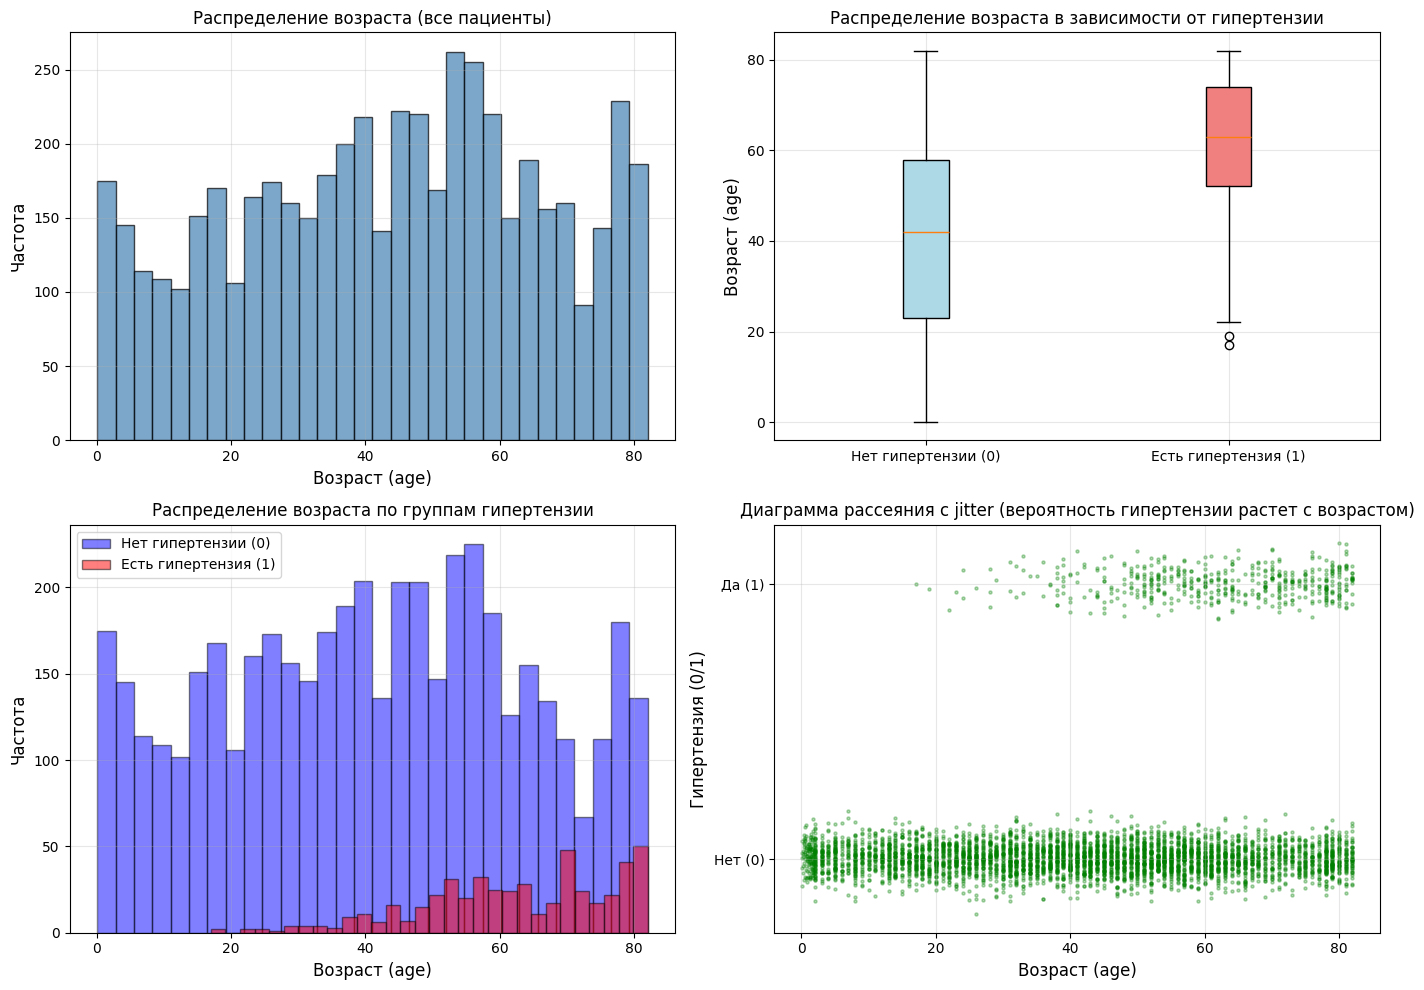

In [ ]:
# 2.2 Визуализация данных

# Извлечение данных
age_data = df_task2['age'].values
hypertension_data = df_task2['hypertension'].values

# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Гистограмма возраста для всей выборки
axes[0, 0].hist(age_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Возраст (age)', fontsize=12)
axes[0, 0].set_ylabel('Частота', fontsize=12)
axes[0, 0].set_title('Распределение возраста (все пациенты)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. Коробчатые диаграммы возраста в зависимости от гипертензии
data_by_hypertension = [age_data[hypertension_data == 0], age_data[hypertension_data == 1]]
bp = axes[0, 1].boxplot(data_by_hypertension, labels=['Нет гипертензии (0)', 'Есть гипертензия (1)'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0, 1].set_ylabel('Возраст (age)', fontsize=12)
axes[0, 1].set_title('Распределение возраста в зависимости от гипертензии', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 3. Гистограммы возраста для двух групп (наложенные)
axes[1, 0].hist(age_data[hypertension_data == 0], bins=30, alpha=0.5, label='Нет гипертензии (0)', color='blue', edgecolor='black')
axes[1, 0].hist(age_data[hypertension_data == 1], bins=30, alpha=0.5, label='Есть гипертензия (1)', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Возраст (age)', fontsize=12)
axes[1, 0].set_ylabel('Частота', fontsize=12)
axes[1, 0].set_title('Распределение возраста по группам гипертензии', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Диаграмма рассеяния с jitter (для наглядности бинарной переменной)
jitter = np.random.normal(0, 0.05, size=len(age_data))
axes[1, 1].scatter(age_data, hypertension_data + jitter, alpha=0.3, s=5, c='green')
axes[1, 1].set_xlabel('Возраст (age)', fontsize=12)
axes[1, 1].set_ylabel('Гипертензия (0/1)', fontsize=12)
axes[1, 1].set_title('Диаграмма рассеяния с jitter (вероятность гипертензии растет с возрастом)', fontsize=12)
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_yticklabels(['Нет (0)', 'Да (1)'])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 2.3 Разделение данных на обучающую и тестовую выборки

### Теория

**Зачем разделять данные:**
- **Обучающая выборка (train)** — на ней модель "учится", подбирает параметры
- **Тестовая выборка (test)** — на ней проверяется, как модель работает на новых, невиданных ранее данных

**Если не разделять данные:**
- Модель может **переобучиться (overfitting)** — запомнить шумы и случайности в обучающих данных
- Оценка качества на тех же данных, где модель училась, будет **оптимистично завышенной**

(В машинном обучении модель нельзя оценивать на тех же данных, на которых она обучалась — это приводит к переобучению (overfitting) и завышенной оценке качества.)

**Стандартное разделение:**
- 70-80% — обучающая выборка
- 20-30% — тестовая выборка

**Стратификация (stratify)** — это метод, при котором пропорции классов сохраняются в обеих выборках. Например, если в исходных данных 10% гипертензии, то и в train, и в test будет примерно 10% гипертензии.

**Почему важна стратификация:**
- Без стратификации может случайно оказаться, что в тестовую выборку попадут только здоровые или только больные
- Это сделает оценку качества некорректной

---


In [ ]:
# 2.3 Разделение данных на обучающую и тестовую выборки

from sklearn.model_selection import train_test_split

# Подготовка данных
X_task2 = df_task2['age'].values.reshape(-1, 1)  # признак (возраст)
y_task2 = df_task2['hypertension'].values         # целевая переменная (гипертензия)

# Разделение: 80% на обучение, 20% на тестирование
X_train, X_test, y_train, y_test = train_test_split(
    X_task2, y_task2, 
    test_size=0.2,      # 20% - тестовая выборка
    random_state=42,    # для воспроизводимости
    stratify=y_task2    # сохраняем пропорцию классов
)

print(f"Размер обучающей выборки (train): {len(X_train)} ({len(X_train)/len(X_task2)*100:.1f}%)")
print(f"  - age: от {X_train.min():.1f} до {X_train.max():.1f}")
print(f"  - гипертензия: 0={np.sum(y_train==0)} записей, 1={np.sum(y_train==1)} записей")
print(f"\nРазмер тестовой выборки (test): {len(X_test)} ({len(X_test)/len(X_task2)*100:.1f}%)")
print(f"  - age: от {X_test.min():.1f} до {X_test.max():.1f}")
print(f"  - гипертензия: 0={np.sum(y_test==0)} записей, 1={np.sum(y_test==1)} записей")

# Проверка сохранения пропорций классов
print(f"\nПроверка стратификации (пропорции классов):")
print(f"  Исходная выборка: доля гипертензии = {np.mean(y_task2):.4f}")
print(f"  Обучающая выборка: доля гипертензии = {np.mean(y_train):.4f}")
print(f"  Тестовая выборка: доля гипертензии = {np.mean(y_test):.4f}")

# Визуализация разделения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограммы для train и test
axes[0].hist(X_train, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(X_test, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0].set_xlabel('Возраст (age)', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('Распределение возраста в train и test выборках', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Доля гипертензии в train и test
categories = ['Train', 'Test']
hypertension_ratio = [np.mean(y_train), np.mean(y_test)]
axes[1].bar(categories, hypertension_ratio, color=['blue', 'orange'], edgecolor='black')
axes[1].set_ylabel('Доля гипертензии', fontsize=12)
axes[1].set_title('Пропорция гипертензии в выборках', fontsize=12)
axes[1].axhline(y=np.mean(y_task2), color='red', linestyle='--', label=f'Исходная доля: {np.mean(y_task2):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'sklearn'

## 2.4 Определение параметров логистического уравнения регрессии

**Логистическая регрессия** — это метод классификации, который предсказывает **вероятность** принадлежности объекта к определённому классу.


Логистическая регрессия моделирует **вероятность** того, что зависимая переменная примет значение 1:

#### Отличие от обычной линейной регрессии

Из презентации:
*"В отличие от обычной регрессии, в методе логистической регрессии регрессионное уравнение f(x) применяется не для предсказания значения отклика исходя из выборки исходных значений. Вместо этого, значением функции является вероятность p(x) того, что данное исходное значение принадлежит к определенному классу, которая задается в виде сигмоиды."*

**Полное уравнение логистической регрессии:**
`P(y=1|x) = 1 / (1 + e^{-(a + b·x)})`

где:
- **p(x)** — вероятность того, что зависимая переменная равна 1 (гипертензия есть)
- **x** — возраст пациента
- **a** — свободный член (intercept)
- **b** — коэффициент при возрасте

#### Свойства сигмоиды

| Свойство | Значение |
|----------|----------|
| Область значений | p(x) ∈ (0, 1) |
| p(x) → 0 при y → -∞ | При очень маленьких значениях x (очень молодой возраст) вероятность близка к 0 |
| p(x) → 1 при y → +∞ | При очень больших значениях x (очень старый возраст) вероятность близка к 1 |
| p(x) = 0.5 при y = 0 | В точке, где линейная комбинация равна 0, вероятность равна 0.5 |

#### Правило классификации

После получения функции вероятности p(x) строится классификатор:

```
Класс = 1, если p(x) ≥ 0.5
Класс = 0, если p(x) < 0.5
```

Порог 0.5 можно менять в зависимости от задачи:
- Если нужно найти всех больных (высокая чувствительность) → понижаем порог
- Если важна точность предсказания (минимум ложных срабатываний) → повышаем порог

#### Интерпретация коэффициента b

- **b > 0** — с увеличением возраста вероятность гипертензии возрастает (график сигмоиды возрастающий)
- **b < 0** — с увеличением возраста вероятность гипертензии убывает (график сигмоиды убывающий)
- **|b|** — чем больше абсолютное значение, тем сильнее влияние возраста (вероятность постоянна)

---


In [ ]:
# 2.4 Определение параметров логистического уравнения регрессии

print("Используется логистическая регрессия для бинарной классификации")
print("Форма модели: p(x) = 1 / (1 + exp(-(a + b*x)))")
print("где p(x) - вероятность наличия гипертензии при заданном возрасте x")

from sklearn.linear_model import LogisticRegression

# Создание и обучение модели логистической регрессии
# Для логистической регрессии используем сигмоидальную функцию
logreg_model = LogisticRegression(random_state=42)

# Обучение модели на обучающей выборке
logreg_model.fit(X_train, y_train)

# Получение параметров модели
a_logreg = logreg_model.intercept_[0]  # свободный член
b_logreg = logreg_model.coef_[0][0]    # коэффициент при возрасте

print(f"\nПараметры логистической регрессии:")
print(f"  Свободный член (intercept) a = {a_logreg:.6f}")
print(f"  Коэффициент при age b = {b_logreg:.6f}")

print(f"\nЛогистическое уравнение регрессии:")
print(f"  p(age) = 1 / (1 + exp(-({a_logreg:.6f} + {b_logreg:.6f} * age)))")

# Функция для вычисления вероятности
def logistic_probability(age, a, b):
    z = a + b * age
    return 1 / (1 + np.exp(-z))

# Примеры предсказаний
print(f"\nПримеры предсказаний вероятности гипертензии:")
for age_example in [30, 50, 70, 80, 90, 100]:
    prob = logistic_probability(age_example, a_logreg, b_logreg)
    pred_class = 1 if prob >= 0.5 else 0
    print(f"  Возраст {age_example} лет: вероятность = {prob:.4f} -> класс = {pred_class} ({'есть гипертензия' if pred_class == 1 else 'нет гипертензии'})")



Используется логистическая регрессия для бинарной классификации
Форма модели: p(x) = 1 / (1 + exp(-(a + b*x)))
где p(x) - вероятность наличия гипертензии при заданном возрасте x

Параметры логистической регрессии:
  Свободный член (intercept) a = -5.014602
  Коэффициент при age b = 0.052851

Логистическое уравнение регрессии:
  p(age) = 1 / (1 + exp(-(-5.014602 + 0.052851 * age)))

Примеры предсказаний вероятности гипертензии:
  Возраст 30 лет: вероятность = 0.0314 -> класс = 0 (нет гипертензии)
  Возраст 50 лет: вероятность = 0.0853 -> класс = 0 (нет гипертензии)
  Возраст 70 лет: вероятность = 0.2116 -> класс = 0 (нет гипертензии)
  Возраст 80 лет: вероятность = 0.3129 -> класс = 0 (нет гипертензии)
  Возраст 90 лет: вероятность = 0.4358 -> класс = 0 (нет гипертензии)
  Возраст 100 лет: вероятность = 0.5672 -> класс = 1 (есть гипертензия)


## 2.5. Получение предсказаний для тестовых данных

### Теория

### Теория

После обучения модели на обучающей выборке (п. 2.4) мы используем её для предсказаний на тестовой выборке.

**Два типа предсказаний:**

1. **Метки классов (predict)**  
   `y_pred = model.predict(X_test)` — результат применения правила классификации (порог 0.15) к вероятностям. Это 0 или 1.
   - Возвращает `0` или `1` для каждого объекта
   - Правило принятия решения: если `P(y=1|x) ≥ 0.5` → класс 1, иначе класс 0

2. **Вероятности (predict_proba)** — p(x) для каждого пациента из тестовой выборки. Это числа от 0 до 1, показывающие, насколько модель "уверена", что у пациента есть гипертензия.
   `y_proba = model.predict_proba(X_test)`
   - Возвращает массив из двух столбцов:  
     - `[:, 0]` — вероятность класса 0  
     - `[:, 1]` — вероятность класса 1  
   - Сумма вероятностей для каждого объекта = 1

**Зачем нужны предсказания на тесте?**  
- **Классы** — нужны для построения матрицы ошибок и расчёта точности
- **Вероятности** — нужны для ROC-кривой и AUC (показывают качество модели независимо от выбранного порога)
Сравнение `y_pred` с реальными `y_test` позволяет оценить, насколько хорошо модель обобщает знания на новые данные. Это главный критерий качества модели.

In [ ]:
# 2.5 Получение предсказаний для тестовых данных

# Предсказание вероятностей
y_pred_prob = logreg_model.predict_proba(X_test)[:, 1]  # вероятность класса 1

porog = 0.15

y_pred_class = (y_pred_prob >= porog).astype(int)

print(f"Предсказания для тестовой выборки (n={len(X_test)}):")
print(f"  Количество предсказанных классов: 0 = {np.sum(y_pred_class==0)}, 1 = {np.sum(y_pred_class==1)}")
print(f"  Диапазон предсказанных вероятностей: [{np.min(y_pred_prob):.4f}, {np.max(y_pred_prob):.4f}]")

# Создание DataFrame для сравнения
results_df = pd.DataFrame({
    'age': X_test.flatten(),
    'true_class': y_test,
    'pred_prob': y_pred_prob,
    'pred_class': y_pred_class
})
print("\nПервые 10 результатов (test выборка):")
print(results_df.head(10).to_string(index=False))



NameError: name 'logreg_model' is not defined

## 2.6. Построение матрицы ошибок (Confusion Matrix)

### Теория

**Матрица ошибок** — это таблица 2×2, которая показывает, сколько и каких ошибок совершила модель при классификации.

|            | Предсказано: 0 | Предсказано: 1 |
|------------|----------------|----------------|
| **Реально: 0** | **TN** (True Negative) | **FP** (False Positive) |
| **Реально: 1** | **FN** (False Negative) | **TP** (True Positive) |   

**Определения:**


| Обозначение | Название | Что означает |
|-------------|----------|--------------|
| **TP** (True Positive) | Верно положительные | Гипертензия есть, модель сказала "есть"  |
| **TN** (True Negative) | Верно отрицательные | Гипертензии нет, модель сказала "нет"  |
| **FP** (False Positive) | Ложно положительные (ошибка I рода) | Гипертензии нет, модель сказала "есть"  |
| **FN** (False Negative) | Ложно отрицательные (ошибка II рода) | Гипертензия есть, модель сказала "нет"  |

#### Метрики качества на основе матрицы ошибок

| Метрика | Формула | Что показывает | Когда важна |
|---------|---------|----------------|-------------|
| **Accuracy** | (TP + TN) / (TP + TN + FP + FN) | Доля правильных ответов | При сбалансированных классах |
| **Precision** | TP / (TP + FP) | Точность предсказания положительного класса | Важно не ошибиться, предсказывая болезнь (дорогое лечение) |
| **Recall** (Sensitivity) | TP / (TP + FN) | Чувствительность — долю больных, которых нашли | Важно не пропустить болезнь (опасно для жизни) |
| **Specificity** | TN / (TN + FP) | Специфичность — долю здоровых, которых правильно определили | Важно не паниковать здоровых |
| **F1-score** | 2 × (P × R) / (P + R) | Гармоническое среднее precision и recall | При несбалансированных классах |


Матрица ошибок:
                 Предсказано
                 Нет (0)   Да (1)
Фактически Нет (0)      922        0
           Да (1)      100        0


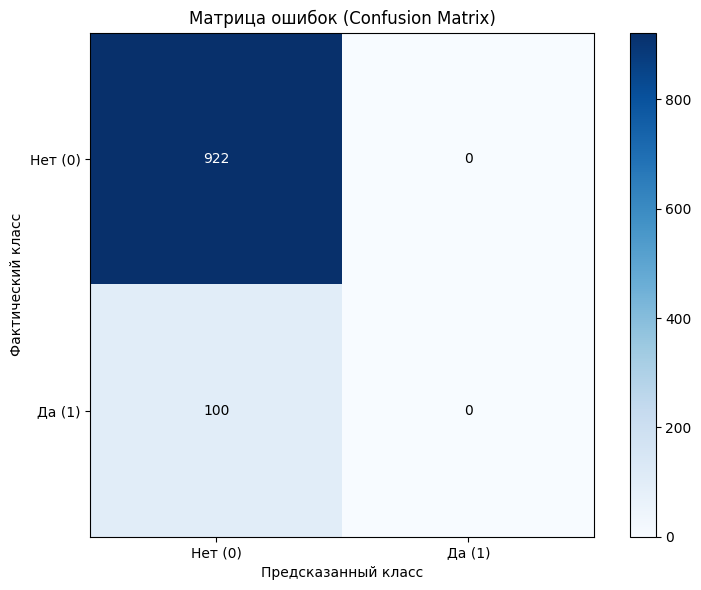


Интерпретация матрицы ошибок:
  True Negatives (TN) = 922 - правильно предсказано отсутствие гипертензии
  False Positives (FP) = 0 - ложно предсказана гипертензия (ошибка I рода)
  False Negatives (FN) = 100 - пропущена гипертензия (ошибка II рода)
  True Positives (TP) = 0 - правильно предсказана гипертензия

--- Метрики качества классификации ---
Accuracy (точность): 0.9022
Precision (положительное предсказательное значение): 0.0000
Recall (чувствительность / полнота): 0.0000
Specificity (специфичность): 1.0000
F1-score: 0.0000

Полный отчет о классификации:
                      precision    recall  f1-score   support

 Нет гипертензии (0)       0.90      1.00      0.95       922
Есть гипертензия (1)       0.00      0.00      0.00       100

            accuracy                           0.90      1022
           macro avg       0.45      0.50      0.47      1022
        weighted avg       0.81      0.90      0.86      1022



c:\Users\Angel\.vscode\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Angel\.vscode\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Angel\.vscode\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# 2.6 Построение матрицы ошибок

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# Расчет матрицы ошибок
cm = confusion_matrix(y_test, y_pred_class)

print("\nМатрица ошибок:")
print("                 Предсказано")
print("                 Нет (0)   Да (1)")
print(f"Фактически Нет (0)   {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"           Да (1)   {cm[1,0]:6d}   {cm[1,1]:6d}")

# Визуализация матрицы ошибок
fig, ax = plt.subplots(figsize=(8, 6))

# Создание тепловой карты
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Настройка меток
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['Нет (0)', 'Да (1)'],
       yticklabels=['Нет (0)', 'Да (1)'],
       xlabel='Предсказанный класс',
       ylabel='Фактический класс',
       title='Матрица ошибок (Confusion Matrix)')

# Добавление значений в ячейки
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# Интерпретация матрицы ошибок
print("\nИнтерпретация матрицы ошибок:")
print(f"  True Negatives (TN) = {cm[0,0]} - правильно предсказано отсутствие гипертензии")
print(f"  False Positives (FP) = {cm[0,1]} - ложно предсказана гипертензия (ошибка I рода)")
print(f"  False Negatives (FN) = {cm[1,0]} - пропущена гипертензия (ошибка II рода)")
print(f"  True Positives (TP) = {cm[1,1]} - правильно предсказана гипертензия")

# Метрики качества классификации
print("\n--- Метрики качества классификации ---")

# Accuracy (точность)
accuracy = (cm[0,0] + cm[1,1]) / np.sum(cm)
print(f"Accuracy (точность): {accuracy:.4f}")

# Precision (точность предсказания положительного класса)
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
print(f"Precision (положительное предсказательное значение): {precision:.4f}")

# Recall (чувствительность)
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
print(f"Recall (чувствительность / полнота): {recall:.4f}")

# Specificity (специфичность)
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
print(f"Specificity (специфичность): {specificity:.4f}")

# F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1-score: {f1_score:.4f}")

print("\nПолный отчет о классификации:")
print(classification_report(y_test, y_pred_class, target_names=['Нет гипертензии (0)', 'Есть гипертензия (1)']))



## 2.7. Выводы по полученным результатам

### Теория (что писать в выводах)

Итоговый вывод должен быть обоснованным, опираться на полученные числовые результаты и отвечать на главный вопрос: **влияет ли выбранная количественная переменная на категориальную и насколько хорошо это влияние описывается моделью?**

При интерпретации результатов логистической регрессии нужно ответить на следующие вопросы:

1. **Значим ли коэффициент b?** (Есть ли вообще связь между возрастом и гипертензией?)
2. **В каком направлении действует связь?** (Положительная или отрицательная)
4. **Какие ошибки допускает модель? (по матрице ошибок)** (FP vs FN — что опаснее?)
5. **Можно ли использовать модель на практике?** (для скрининга, диагностики, исследований)
6. **Итоговый вывод**  
   Принимается или отвергается гипотеза о наличии влияния количественной переменной на категориальную. Оценивается практическая применимость модели для прогнозирования.

#### Важные замечания:

- **Логистическая регрессия не требует нормальности** данных (в отличие от линейной регрессии и корреляции Пирсона)
- Коэффициенты интерпретируются в терминах **логарифма шансов (log-odds)**, но для простоты можно говорить о положительном/отрицательном влиянии
- **Корреляция не равна причинности** — даже если модель показывает хорошее качество, это не доказывает, что возраст *является причиной* гипертензии, а не просто связан с ней


In [ ]:
# 2.7 Выводы по полученным результатам
print("\n1. Параметры модели:")
print(f"   Логистическая регрессия: p(age) = 1 / (1 + exp(-({a_logreg:.4f} + {b_logreg:.4f}·age)))")
if b_logreg > 0:
    print(f"   Коэффициент при возрасте положительный ({b_logreg:.4f}) → с увеличением возраста")
    print("   вероятность гипертензии возрастает.")
else:
    print(f"   Коэффициент при возрасте отрицательный ({b_logreg:.4f}) → с увеличением возраста")
    print("   вероятность гипертензии убывает.")

print("\n2. Качество классификации:")
print(f"   Accuracy (общая точность): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} (из всех предсказанных 'гипертензия', правильных {precision*100:.2f}%)")
print(f"   Recall: {recall:.4f} (из всех реальных 'гипертензия', найдено {recall*100:.2f}%)")
print(f"   F1-score: {f1_score:.4f} (гармоническое среднее precision и recall)")

print("\n3. Анализ ошибок:")
total_errors = cm[0,1] + cm[1,0]
print(f"   Всего ошибок на тестовой выборке: {total_errors} из {len(X_test)} ({total_errors/len(X_test)*100:.2f}%)")
print(f"   Ложноположительные (FP): {cm[0,1]} - пациент здоров, но модель предсказала гипертензию")
print(f"   Ложноотрицательные (FN): {cm[1,0]} - пациент болен, но модель не выявила гипертензию")


1. Параметры модели:
   Логистическая регрессия: p(age) = 1 / (1 + exp(-(-5.0146 + 0.0529·age)))
   Коэффициент при возрасте положительный (0.0529) → с увеличением возраста
   вероятность гипертензии возрастает.

2. Качество классификации:
   Accuracy (общая точность): 0.9022 (90.22%)
   Precision: 0.0000 (из всех предсказанных 'гипертензия', правильных 0.00%)
   Recall: 0.0000 (из всех реальных 'гипертензия', найдено 0.00%)
   F1-score: 0.0000 (гармоническое среднее precision и recall)

3. Анализ ошибок:
   Всего ошибок на тестовой выборке: 100 из 1022 (9.78%)
   Ложноположительные (FP): 0 - пациент здоров, но модель предсказала гипертензию
   Ложноотрицательные (FN): 100 - пациент болен, но модель не выявила гипертензию


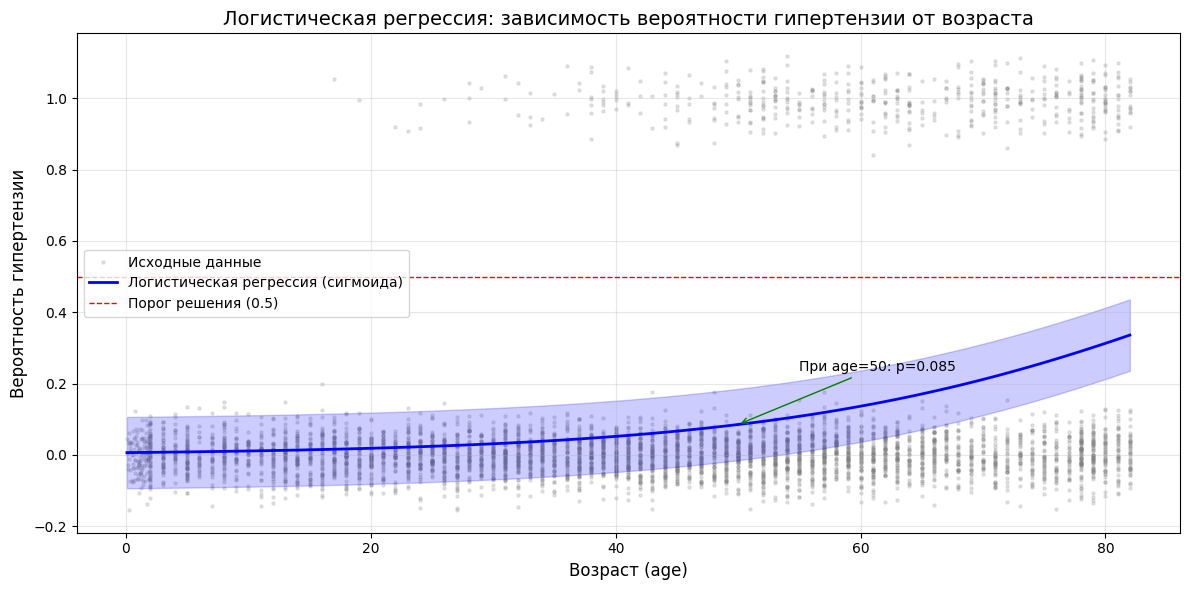

In [ ]:

# Визуализация логистической регрессии
fig, ax = plt.subplots(figsize=(12, 6))

# Сортируем данные для плавной кривой
age_range = np.linspace(X_task2.min(), X_task2.max(), 100).reshape(-1, 1)
prob_range = logreg_model.predict_proba(age_range)[:, 1]

# Исходные данные с jitter
jitter = np.random.normal(0, 0.05, size=len(X_task2))
ax.scatter(X_task2, y_task2 + jitter, alpha=0.2, s=5, c='gray', label='Исходные данные')

# Сигмоида (логистическая кривая)
ax.plot(age_range, prob_range, 'b-', linewidth=2, label='Логистическая регрессия (сигмоида)')

# Порог принятия решения (0.5)
ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Порог решения (0.5)')

# Доверительная область (неформальная)
ax.fill_between(age_range.flatten(), 
                 prob_range - 0.1, 
                 prob_range + 0.1, 
                 alpha=0.2, color='blue')

ax.set_xlabel('Возраст (age)', fontsize=12)
ax.set_ylabel('Вероятность гипертензии', fontsize=12)
ax.set_title('Логистическая регрессия: зависимость вероятности гипертензии от возраста', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Добавление аннотаций
ax.annotate(f'При age=50: p={logistic_probability(50, a_logreg, b_logreg):.3f}', 
            xy=(50, logistic_probability(50, a_logreg, b_logreg)), 
            xytext=(55, logistic_probability(50, a_logreg, b_logreg)+0.15),
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

| Этап | Описание этапа | Задание №1 (Линейная регрессия, age → bmi) | Задание №2 (Логистическая регрессия, age → hypertension) |
|------|----------------|----------------------------------------------|----------------------------------------------------------|
| 1 | Подготовка данных | + Удалили пропуски в age и bmi, привели к числам | + Удалили пропуски в age и hypertension, привели к числам |
| 2 | Визуализация данных | + scatter plot, гистограммы, boxplot | + scatter plot с jitter, гистограммы, boxplot |
| 3 | Выбор вида уравнения | + Линейная (y=a+bx). Проверили полиномом 2й ст.: R² почти не выше, adj R² ниже → нелинейности нет | + Логистическая регрессия (бинарная классификация, предсказание вероятности). Линейная не подходит (выход за [0,1]) |
| 4 | Нахождение оценок параметров θ | + МНК (минимизация суммы квадратов ошибок) | + Метод максимального правдоподобия (ошибки биномиальны, не нормальны) |
| 5 | Нахождение доверительных интервалов и оценка значимости параметров | + 95% ДИ для a и b (statsmodels). Интервал не содержит 0 → коэффициент значим | – Не делали (sklearn не выдаёт, в задании не требовалось) |
| 6 | Оценка качества модели | + R² и adj R² (доля объяснённой дисперсии) | + Accuracy, Precision, Recall, F1 (для классификации) |
| 7 | Оценка статистической значимости регрессии целиком (критерий Фишера) | + F-статистика, p-value (p<0.05 → модель значима) | – Не делали (аналог — тест отношения правдоподобия, но не требовался) |
| 8 | Прогноз значений зависимой переменной | + предсказали bmi для age=30, 50, 70 | + предсказали вероятность и класс (0/1) для новых age |
| Доп. 1 | Проверка нормальности распределения | + age и bmi не нормальны → использовали корреляцию Спирмена (а не Пирсона) | – Не требуется (логистическая регрессия не требует нормальности x) |
| Доп. 2 | Коэффициент корреляции (Пирсон / Спирмен) | + Спирмен (ранговый), r_s ≈ 0.12 → очень слабая связь | – Не нужен (оценка через логистическую регрессию) |
| Доп. 3 | Доверительные интервалы для коэффициента корреляции | **Зачем:** r_s=0.12 — точечная оценка. ДИ показывает диапазон для генеральной совокупности. Если ДИ не содержит 0 → связь значима.<br>**Как строили:** процентильный бутстрап-интервал. Извлекали B=1000 выборок с возвращением из пар (age, bmi), вычисляли r_s для каждой, брали 2.5% и 97.5% процентили. T-интервал (преобразование Фишера) не использовали, т.к. он только для Пирсона (требует нормальности), а у нас данные не нормальны и мы использовали Спирмена. | – |
| Доп. 4 | Бутстрап (bootstrap) — что это и почему использовали | + **Что такое бутстрап?** Метод многократной случайной выборки с возвращением из исходных данных. Не требует теоретических формул и предположений о нормальности.<br>**Почему использовали?** Для построения ДИ для коэффициента корреляции Спирмена, т.к. данные не нормальны и аналитические формулы для ДИ ранговой корреляции сложны и менее точны. Бутстрап даёт надёжную оценку без дополнительных допущений. | – |

**Почему использовали бутстрап, а не теоретические формулы?** 
1. Данные не нормальны → теоретические формулы (преобразование Фишера) могут быть неверны.
2. Мы использовали коэффициент Спирмена (ранговый) → для него нет простой теоретической формулы доверительного интервала.
3. Бутстрап универсален: работает для любых данных и любых статистик (среднее, корреляция, медиана и т.д.).

**Как работали:**
1. Из исходных пар (age, bmi) сделали B=1000 выборок с возвращением.
2. Для каждой вычислили r_s.
3. Построили распределение r_s.
4. Взяли 2.5% и 97.5% процентили → получили 95% доверительный интервал для r_s. | - Не нужен. |